# 01 — What is Control? States, Controls, Targets and Feedback

**Mathematical Foundations of Control and Machine Learning — Winter 2026**

> **Central question.** *What does it mean mathematically to act on a dynamical system?*

This notebook makes the vocabulary of the course precise — state, control, target, feedback — compares the three basic control questions.

### Table of Contents

1. **The ingredients of a control problem** — state equation, admissible controls, objective
2. **Three different questions** — optimal control, controllability, stabilization; open and closed loop
3. **The overdamping paradox** — energy decays faster, the state returns slower
4. **Control ↔ ML: two forward connections** — reinforcement learning and momentum
5. **Exercises**

**Appendix A.** A short history — from Ktesibios's water clock to the state-space revolution

In [1]:
%matplotlib inline
import numpy as np
import torch
import matplotlib.pyplot as plt
import plotting as P           # the course palette, the house style, and the figure helpers

torch.manual_seed(0);

In [2]:
# RK4 integrator for x' = f(t, x) along the time grid ts
def odeint(f, x0, ts):
    xs = [x0]
    for t, t1 in zip(ts[:-1], ts[1:]):
        x, h = xs[-1], t1 - t
        k1 = f(t, x)
        k2 = f(t + h / 2, x + h / 2 * k1)
        k3 = f(t + h / 2, x + h / 2 * k2)
        k4 = f(t + h, x + h * k3)
        xs.append(x + h / 6 * (k1 + 2 * k2 + 2 * k3 + k4))
    return torch.stack(xs)

## Where are we?

A system has a *state* that evolves in time, we act on it through a *control*, and we want to reach a *target*. Here we make these words precise, compare the three basic control questions, and study the first example where intuition about control fails, the overdamped oscillator.

## 1. The ingredients of a control problem

A **state equation** describes how the state evolves and where we can act. For most cases, we consider a system of ordinary differential equations (ODEs) of the form
$$
x'(t)=f\big(x(t),u(t)\big),\quad t\in(0,T),\qquad x(0)=x^0,
$$
where $x(t)\in\mathbb R^n$ is the **state** to be controlled and $u(t)\in\mathbb R^m$ is the **control**, taken from a set of **admissible controls** $\mathcal U_{ad}$. Typical choices are $\mathcal U_{ad}=L^2(0,T;\mathbb R^m)$ or controls with bounds, $|u(t)|\le1$.

The same framework covers very different models: linear or nonlinear, deterministic or stochastic, finite- or infinite-dimensional, ordinary or partial differential equations, as well as hybrid models.


> **Example (the harmonic oscillator).** The oscillator with a force, $x_1''+x_1=u$, becomes a first-order system for $x=(x_1,x_2)=(\text{position},\text{velocity})$:
> $$
> x'=\begin{pmatrix}0&1\\-1&0\end{pmatrix}x+\begin{pmatrix}0\\1\end{pmatrix}u=A\,x+B\,u .
> $$
> It has one control acting on a two-dimensional state.

## 2. Three different questions

Several kinds of control problems fit the same framework, depending on how the objective is formulated.

**Optimal control.** Choose $u\in\mathcal U_{ad}$ to minimize a cost, for example the distance to the target, or that distance plus the effort spent:
$$
\min_{u\in\mathcal U_{ad}}\ J(u),\qquad J(u)=|x(T)-x^1|^2+\alpha\int_0^T|u(t)|^2dt .
$$
The answer is an *optimal control*. It need not reach the target: it makes the best compromise allowed by the cost.

**Controllability.** Given $x^0$, $x^1$ and $T$, is there $u\in\mathcal U_{ad}$ such that $x(T)=x^1$ *exactly*? This is a more dynamical notion. The relaxed version, **approximate controllability**, asks for $|x(T)-x^1|\le\varepsilon$ for every $\varepsilon>0$.

**Stabilization (feedback control).** Find a *rule* $u=F(x)$ such that every solution of the closed-loop system
$$
x'=f\big(x,F(x)\big)
$$
tends to an equilibrium. The control is computed in real time from the state.

The last question introduces a distinction that runs through the whole course. A control can be

1. **open loop**, $u=u(t)$: a function of time, computed in advance from the model and then applied blindly;
2. **closed loop** or **feedback**, $u=F(x(t))$: computed in real time from the current state, so it can react to disturbances the model does not know about.

<!-- The *concept of feedback* comes from the capacity of biological systems to regulate themselves. It was incorporated into control engineering in the 1920s by engineers of the Bell Telephone Laboratories. In a feedback process, *the state of the system determines the way the control has to be exerted in real time*: the cause–effect principle becomes a **cause–effect–cause** principle. Classical examples include the thermostat, aircraft and vehicles in motion, and noise reduction. -->


## 3. The overdamping paradox

**The model.** Without friction, the linearized pendulum $x_1''+x_1=0$ conserves its energy
$$
e(t)=\tfrac12\big(x_1(t)^2+x_1'(t)^2\big).
$$
With friction proportional to the velocity,
$$
x_1''+x_1=-kx_1',\qquad k>0 .
$$
The control is $u=-kx_2$ with a feedback law where the control opposes the measured velocity.

**Energy decreases.** Along solutions,
$$
e'(t)=x_1x_1'+x_1'x_1''=x_1'\,(x_1+x_1'')=-k\,(x_1')^2\;\le\;0 .
$$
So more damping removes energy faster *at each instant*, for the same velocity. Does it follow that a larger $k$ always brings the system to rest faster?


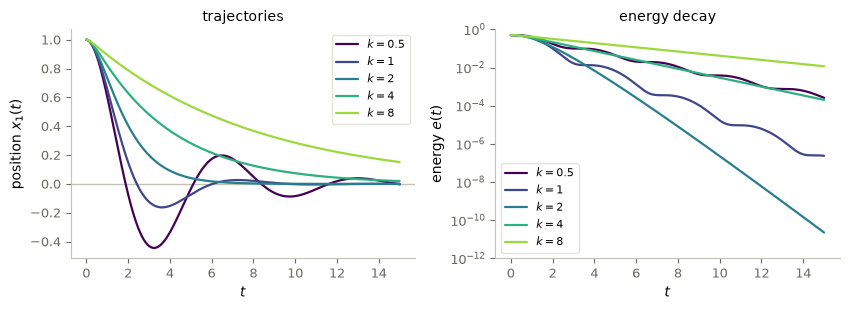

In [4]:
ks = [0.5, 1.0, 2.0, 4.0, 8.0]
x0 = torch.tensor([1.0, 0.0])
ts15 = torch.linspace(0, 15, 1501)

sols = {}
for k in ks:
    A_k = torch.tensor([[0.0, 1.0], [-1.0, -k]])       # the oscillator under the feedback u = -k x2
    sols[k] = odeint(lambda t, x: A_k @ x, x0, ts15)

shades = plt.cm.viridis(np.linspace(0, 0.85, len(ks)))
fig, (ax1, ax2) = P.panels(2, size=(4.3, 3.2))
for (k, x), c in zip(sols.items(), shades):
    ax1.plot(ts15, x[:, 0], color=c, label=f"$k={k:g}$")
    ax2.semilogy(ts15, 0.5 * (x ** 2).sum(1), color=c, label=f"$k={k:g}$")
P.label(ax1, "$t$", "position $x_1(t)$", title="trajectories", zero="h")
P.label(ax2, "$t$", "energy $e(t)$", title="energy decay", ylim=(1e-12, 1))
plt.show()

## 4. Control ↔ ML: two forward connections

- **Feedback ↔ reinforcement learning.** Reinforcement learning is "learning based on feedback": there are no correct input–output pairs, but there is a reward. The common idea is that an action depends on the observed state. The difference is that a feedback law is *designed* from a known model, while in reinforcement learning a policy is *learned* from rewards.
- **Damping ↔ momentum methods.** The "heavy ball" picture of momentum in gradient descent is a damped second-order dynamics. Its damping parameter can be too small, giving oscillations, or too large, giving slow creeping, exactly as in the decay-rate figure above.

## Key takeaways

1. A control problem consists of a state equation, a set of admissible controls and an objective.
2. Controllability: *can* the target be reached? Optimal control: which admissible control is *best*? Stabilization: is there a *rule* $u=F(x)$ that makes the equilibrium asymptotically stable (stable and attracting), here for every initial state?
3. Open loop: $u=u(t)$, computed in advance. Closed loop: $u=F(x(t))$, computed in real time from the state, so it can correct for unknown disturbances.
4. Viscous damping is the feedback $u=-kx_2$, and it makes the energy non-increasing: $e'=-k(x_1')^2$.
5. The decay rate is $r(k)=k/2$ for $k\le2$ and $2/(k+\sqrt{k^2-4})$ for $k\ge2$: it is maximal at critical damping, $k=2$, and tends to $0$ as $k\to\infty$.

## 5. Exercises

★ conceptual · ★★ mathematical · ★★★ computational

1. **Which question is it? ★** Classify each problem as controllability, optimal control or stabilization, and say what the unknown is: (a) keep an inverted pendulum upright despite small pushes; (b) bring a crane load from rest at one point to rest at another point in exactly 20 s; (c) among all ways of doing (b), find the one using the least energy; (d) cruise control keeps a car at 100 km/h on hills.
2. **The oscillator. ★★** (a) Verify that $x_1(t)=(1+t)e^{-t}$ solves $x_1''+2x_1'+x_1=0$ with $x_1(0)=1$, $x_1'(0)=0$. (b) For $k>2$, show that $r(k)=2/(k+\sqrt{k^2-4})$ is strictly decreasing, and that $k\,r(k)\to1$ as $k\to\infty$. (c) For $k>2$ and $x^0=(1,0)$, write the solution as $c_+e^{\lambda_+t}+c_-e^{\lambda_-t}$ and show that both coefficients are nonzero, so that the slow rate is actually observed.
3. **Open loop versus feedback. ★★** Consider the thermostat model $x'=-x+u+d$ for a temperature deviation $x$, with setpoint $1$ and an unknown constant disturbance $d$. (a) compute the limit of $x(t)$ for the open-loop control $u\equiv1$ and for the feedback $u=1+L(1-x)$, for a constant unknown $d$; (b) show that the feedback error tends to $0$ as $L\to\infty$; (c) now assume that the *measurement* is wrong by a constant bias $\beta$, so the feedback uses $x+\beta$ instead of $x$. What is the limit, and what does a large $L$ do to the effect of $\beta$?
4. **Energy is not enough. ★★** For $x_1''+kx_1'+x_1=0$ we showed $e'=-k(x_1')^2\le0$. (a) Does this inequality alone prove that $e(t)\to0$? Find the weak point. (b) Use the characteristic roots to prove that $e(t)\to0$ exponentially for every $k>0$.
5. **A stiffer spring. ★★★** Consider $x_1''+kx_1'+\omega^2x_1=0$ with $\omega>0$. Modify the decay-rate code of §4.1 to compute $r(k;\omega)$ numerically for $\omega\in\{0.5,1,2\}$ and $0<k\le10$. Find the best damping $k^*(\omega)$ and the best rate, and conjecture formulas. Then prove them from the characteristic roots.

In [6]:
# TODO: student exercise (Exercise 5)
# Build A = [[0, 1], [-omega**2, -k]] and compute the decay rate -max Re(eig(A)) on a grid of k,
# for omega in [0.5, 1, 2]. Plot the rates against k and locate the maximum.

def decay_rate(k, omega):
    ...  # your code here
    return None

## Where are we going?

We have three questions and one example. [Notebook 02](02_linear_control_kalman.ipynb) takes the first question, controllability, for linear systems $x'=Ax+Bu$. It asks when a few controls can steer a system between arbitrary states, and it answers with the Kalman rank condition and an explicit steering control.

## Appendix A. A short history

In the third century BCE, [Ktesibios's water clock](https://collection.kotsanasmuseum.com/en/exhibits/106045/) used a float valve to keep its water supply steady — and antiquity already saw automation as a source of freedom, in a passage of Aristotle's *Politics*. [Windmills used fantails](https://millsarchive.org/2016/09/06/from-quern-to-computer-the-history-of-flour-milling/9/) to turn into the wind automatically. In 1788, [James Watt fitted a centrifugal governor to a steam engine](https://collection.sciencemuseumgroup.org.uk/objects/co50948/rotative-steam-engine-by-boulton-and-watt-1788): as two rotating balls moved outward, they adjusted a valve that controlled the steam supply. These devices worked, but a general mathematical account of their stability came later.

![Illustration of a centrifugal governor](images/governor_maxwell.png)

By the 1860s, engineers faced a practical problem: making a governor more responsive could cause it to oscillate, or *hunt*. In [*On Governors* (1868)](https://doi.org/10.1098/rspl.1867.0055), James Clerk Maxwell described small departures from steady operation with linear differential equations. He related stability to the roots of a characteristic polynomial: disturbances die away when every root has a negative real part — §4 is the simplest instance of his analysis. In 1907, H. R. Hall stressed that regulators *need* fluctuations, which should be diminished but not removed.

In the 1920s–1930s, feedback entered telecommunications at the Bell Laboratories, and automatic control spread rapidly, along two parallel approaches: state space (ODEs) and frequency domain (Fourier). In 1948, N. Wiener named the field in [*Cybernetics*](https://mitpress.mit.edu/9780262730099/cybernetics/), "the science of control and communication in animals and machines".

In the 1950s and early 1960s, [Bellman's dynamic programming](https://doi.org/10.1090/S0002-9904-1954-09848-8), [Pontryagin's maximum principle](https://www.mathnet.ru/eng/im3547) (a far-reaching generalization of Lagrange multipliers) and [Kalman's work on optimal control](https://liberzon.csl.illinois.edu/teaching/kalman_paper.pdf) established modern state-space control. Kalman developed the concepts of **controllability** and **observability** and analyzed the linear–quadratic regulator using a Riccati equation. His [1960 paper on filtering](https://doi.org/10.1115/1.3662552) addressed a different task — estimating a system's state from noisy measurements — and was later used in [Apollo's onboard navigation](https://web.mit.edu/digitalapollo/Documents/Chapter5/mitroleapollovi.pdf). The theory then grew towards nonlinear, stochastic and infinite-dimensional (PDE) systems, with applications from acoustics and quantum control to aerospace, biomedicine and energy.

## References

1. J. C. Maxwell, [*On governors*](https://doi.org/10.1098/rspl.1867.0055), Proceedings of the Royal Society of London **16** (1868), 270–283.
2. N. Wiener, [*Cybernetics: or Control and Communication in the Animal and the Machine*](https://mitpress.mit.edu/9780262730099/cybernetics/), MIT Press, 1948.
3. R. Bellman, [*The theory of dynamic programming*](https://doi.org/10.1090/S0002-9904-1954-09848-8), Bulletin of the AMS **60** (1954), 503–515.
4. L. S. Pontryagin, V. G. Boltyanskii, R. V. Gamkrelidze, E. F. Mishchenko, [*The Mathematical Theory of Optimal Processes*](https://www.routledge.com/The-Mathematical-Theory-of-Optimal-Processes/Pontryagin/p/book/9782881240775), Interscience, 1962.
5. R. E. Kalman, [*Contributions to the theory of optimal control*](https://liberzon.csl.illinois.edu/teaching/kalman_paper.pdf), Boletín de la Sociedad Matemática Mexicana **5** (1960), 102–119.
6. E. D. Sontag, [*Mathematical Control Theory: Deterministic Finite Dimensional Systems*](https://doi.org/10.1007/978-1-4612-0577-7), 2nd ed., Springer, 1998.
7. K. J. Åström, R. M. Murray, [*Feedback Systems: An Introduction for Scientists and Engineers*](https://www.cds.caltech.edu/~murray/FBS/Second_Edition.html), 2nd ed., Princeton University Press, 2021.